# Supply & Demand Zone Strategy Builder

This notebook implements a programmatic Supply & Demand zone detection algorithm with **lookahead bias removed** and **zone invalidation** properly tracked.

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams['axes.grid'] = True

## 1. Load Data for Multiple Stocks
We load a small sample of stocks to test the robustness of the zone identification.

In [2]:
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]

loaded_stocks = {}
for file in all_files:
    try:
        df = pd.read_csv(os.path.join(DATA_DIR, file))
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        # Basic filter to ensure we have enough data and it's somewhat active
        if len(df) > 1000:
            loaded_stocks[file.replace('.csv', '')] = df
            
        if len(loaded_stocks) >= 10:  # Load 10 stocks for our test sample
            break
    except Exception as e:
        continue

print(f"Loaded {len(loaded_stocks)} stocks for testing.")

Loaded 10 stocks for testing.


## 2. Refined Zone Detection Logic
Updates:
- **Fixed Lookahead Bias:** Zones are only created at `out_end` (after the confirmation window).
- **Invalidation:** Zones expire when price closes beyond their distal lines.

In [3]:
def add_atr(data, period=14):
    data = data.copy()
    prev_close = data['Close'].shift(1)
    tr1 = data['High'] - data['Low']
    tr2 = (data['High'] - prev_close).abs()
    tr3 = (data['Low'] - prev_close).abs()
    data['TR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    data['ATR'] = data['TR'].rolling(period, min_periods=period).mean()
    return data

def detect_supply_demand_zones(
    data,
    min_base_candles=2,
    max_base_candles=6,
    base_atr_multiplier=1.20,
    move_lookahead=5,
    move_atr_multiplier=1.80,
    min_move_pct=3.0,
):
    zones = []
    data = add_atr(data)
    n = len(data)

    for start in range(20, n - max_base_candles - move_lookahead):
        for base_len in range(min_base_candles, max_base_candles + 1):
            end = start + base_len - 1
            out_end = end + move_lookahead
            base = data.iloc[start:end + 1]
            after = data.iloc[end + 1:out_end + 1]
            atr = data.loc[end, 'ATR']

            if not np.isfinite(atr) or atr <= 0:
                continue

            base_high = base['High'].max()
            base_low = base['Low'].min()
            base_range = base_high - base_low
            base_mid = (base_high + base_low) / 2
            base_range_pct = (base_range / base_mid) * 100 if base_mid else np.nan

            if base_range > atr * base_atr_multiplier:
                continue

            base_close = data.loc[end, 'Close']
            max_after_high = after['High'].max()
            min_after_low = after['Low'].min()
            rally_move = max_after_high - base_close
            drop_move = base_close - min_after_low
            rally_pct = (rally_move / base_close) * 100 if base_close else 0
            drop_pct = (drop_move / base_close) * 100 if base_close else 0

            # Demand zone
            if rally_move >= atr * move_atr_multiplier and rally_pct >= min_move_pct:
                body_high = base[['Open', 'Close']].max(axis=1).max()
                zones.append({
                    'type': 'demand',
                    'start_idx': start,
                    'end_idx': end,
                    'created_idx': out_end,  # Lookahead bias fixed
                    'zone_low': base_low,
                    'zone_high': body_high,
                    'move_pct': rally_pct,
                    'base_range_pct': base_range_pct,
                    'score': rally_pct / max(base_range_pct, 0.01),
                })

            # Supply zone
            if drop_move >= atr * move_atr_multiplier and drop_pct >= min_move_pct:
                body_low = base[['Open', 'Close']].min(axis=1).min()
                zones.append({
                    'type': 'supply',
                    'start_idx': start,
                    'end_idx': end,
                    'created_idx': out_end,  # Lookahead bias fixed
                    'zone_low': body_low,
                    'zone_high': base_high,
                    'move_pct': drop_pct,
                    'base_range_pct': base_range_pct,
                    'score': drop_pct / max(base_range_pct, 0.01),
                })

    zones_df = pd.DataFrame(zones)
    if len(zones_df) > 0:
        zones_df['start_date'] = zones_df['start_idx'].map(data['Date'])
        zones_df['end_date'] = zones_df['end_idx'].map(data['Date'])
        zones_df = zones_df.sort_values(['created_idx', 'score'], ascending=[True, False]).reset_index(drop=True)
        
        # Add invalidation tracking
        zones_df['invalidated_idx'] = np.inf
        
        for i, row in zones_df.iterrows():
            created_idx = row['created_idx']
            future_data = data.iloc[created_idx:]
            
            if row['type'] == 'demand':
                breaches = future_data[future_data['Close'] < row['zone_low']]
                if not breaches.empty:
                    zones_df.at[i, 'invalidated_idx'] = breaches.index[0]
            else:
                breaches = future_data[future_data['Close'] > row['zone_high']]
                if not breaches.empty:
                    zones_df.at[i, 'invalidated_idx'] = breaches.index[0]
                    
    return data, zones_df

print("Detection functions loaded.")

Detection functions loaded.


## 3. Dynamic Zone Plotting
Plotting logic updated to stop drawing zones once they reach their `invalidated_idx`.

In [4]:
def plot_candles_with_zones(data, zones_df, symbol, lookback=260, max_zones=20):
    plot_data = data.tail(lookback).copy().reset_index(drop=False).rename(columns={'index': 'original_idx'})
    min_original_idx = int(plot_data['original_idx'].min())
    max_original_idx = int(plot_data['original_idx'].max())

    if len(zones_df) == 0:
        print(f"No zones found for {symbol}")
        return

    # Filter for zones that existed during the plot window
    active_zones = zones_df[
        (zones_df['created_idx'] <= max_original_idx) &
        (zones_df['invalidated_idx'] >= min_original_idx)
    ].tail(max_zones).copy()

    fig, ax = plt.subplots(figsize=(18, 9))
    width = 0.65

    # Draw zones
    for _, z in active_zones.iterrows():
        x0 = max(0, int(z['end_idx'] - min_original_idx))
        end_idx = min(z['invalidated_idx'], max_original_idx)
        x1 = int(end_idx - min_original_idx)
        
        if x1 <= x0:
            continue
            
        color = 'green' if z['type'] == 'demand' else 'red'
        alpha = 0.14 if z['type'] == 'demand' else 0.12
        
        ax.add_patch(Rectangle(
            (x0, z['zone_low']),
            max(1, x1 - x0),
            z['zone_high'] - z['zone_low'],
            color=color,
            alpha=alpha,
            linewidth=0,
        ))
        ax.text(x0, z['zone_high'], f"{z['type']} {z['score']:.1f}", color=color, fontsize=8, va='bottom')

    # Draw candles
    for i, row in plot_data.iterrows():
        o, h, l, c = row['Open'], row['High'], row['Low'], row['Close']
        color = '#16a34a' if c >= o else '#dc2626'
        ax.plot([i, i], [l, h], color=color, linewidth=1)
        body_low = min(o, c)
        body_height = max(abs(c - o), 0.001)
        ax.add_patch(Rectangle((i - width/2, body_low), width, body_height, color=color, alpha=0.85))

    tick_step = max(1, len(plot_data) // 10)
    ticks = list(range(0, len(plot_data), tick_step))
    labels = [plot_data.loc[t, 'Date'].strftime('%Y-%m-%d') for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(f'{symbol} Supply/Demand Zones - Last {lookback} Candles')
    ax.set_ylabel('Price')
    plt.tight_layout()
    plt.show()



## 4. Evaluate Sample Stocks
Let's run the algorithm on a few of our loaded stocks.


Processing 360ONE...


Detected 537 zones for 360ONE


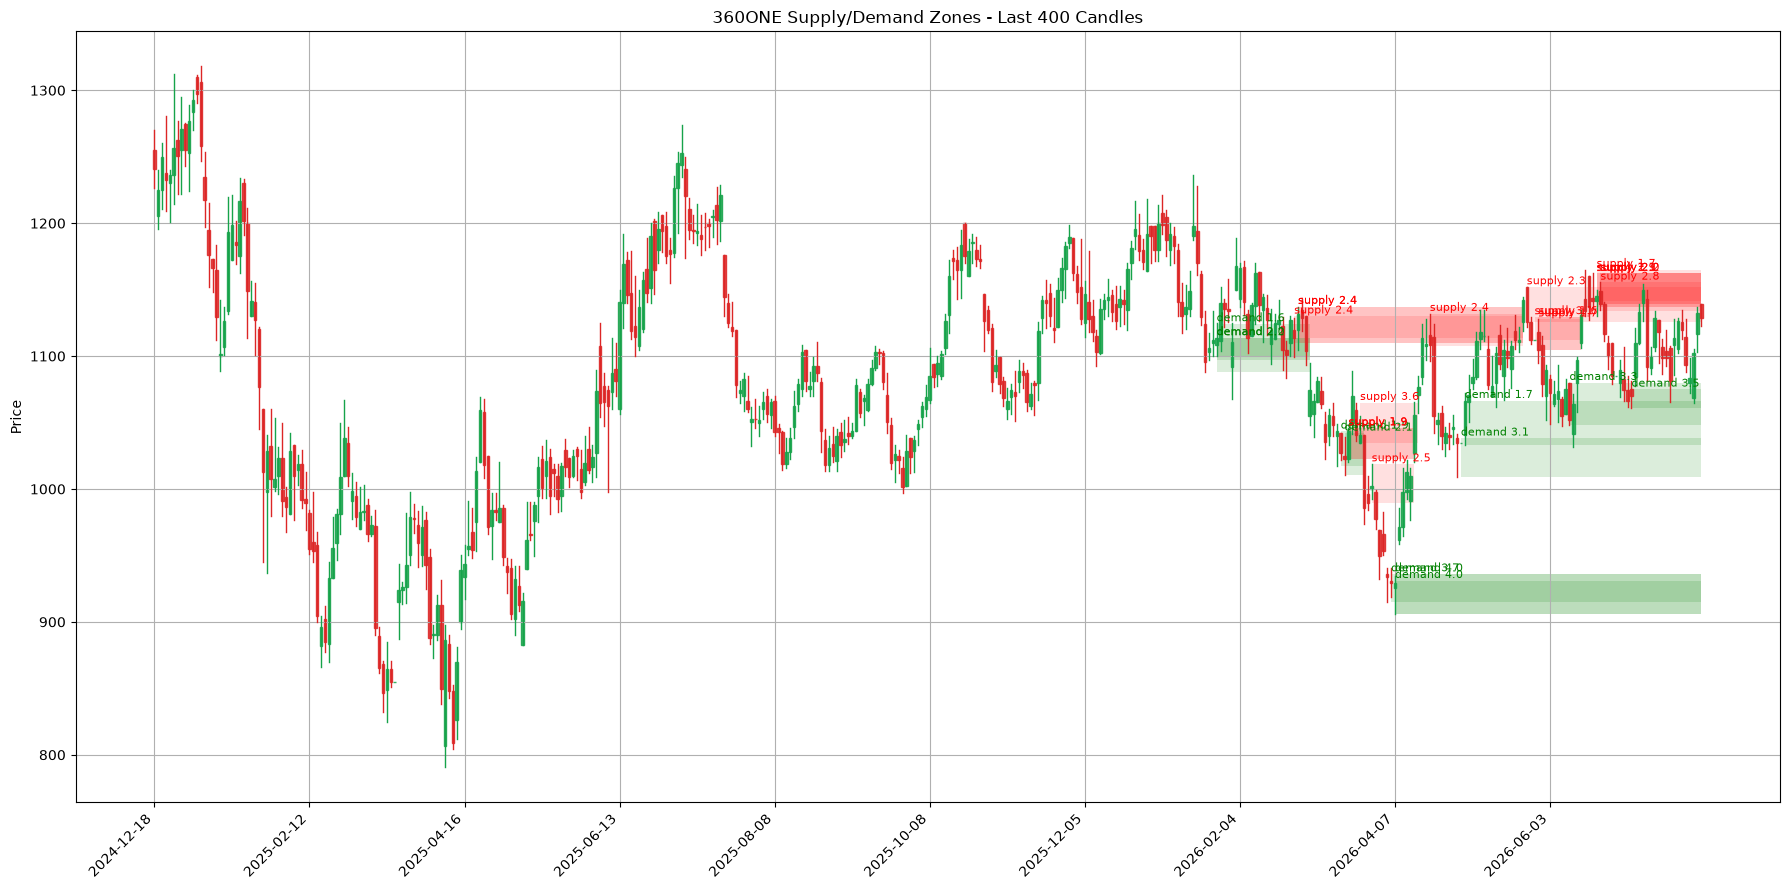


Processing 3MINDIA...


Detected 703 zones for 3MINDIA


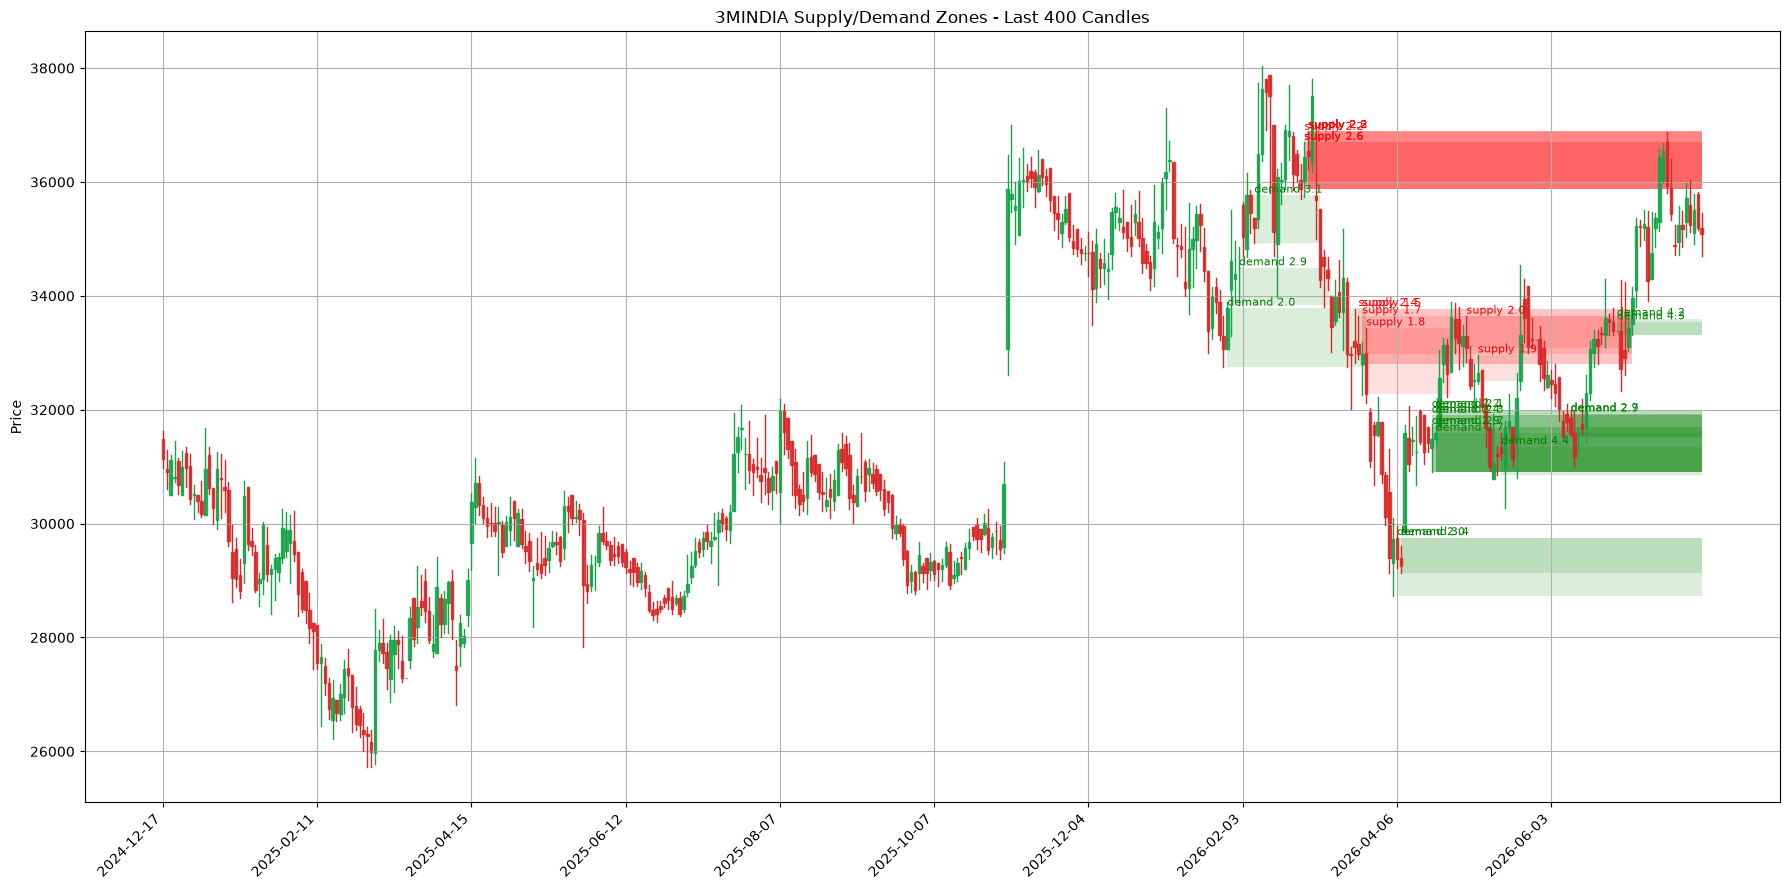


Processing AARTIDRUGS...


Detected 883 zones for AARTIDRUGS


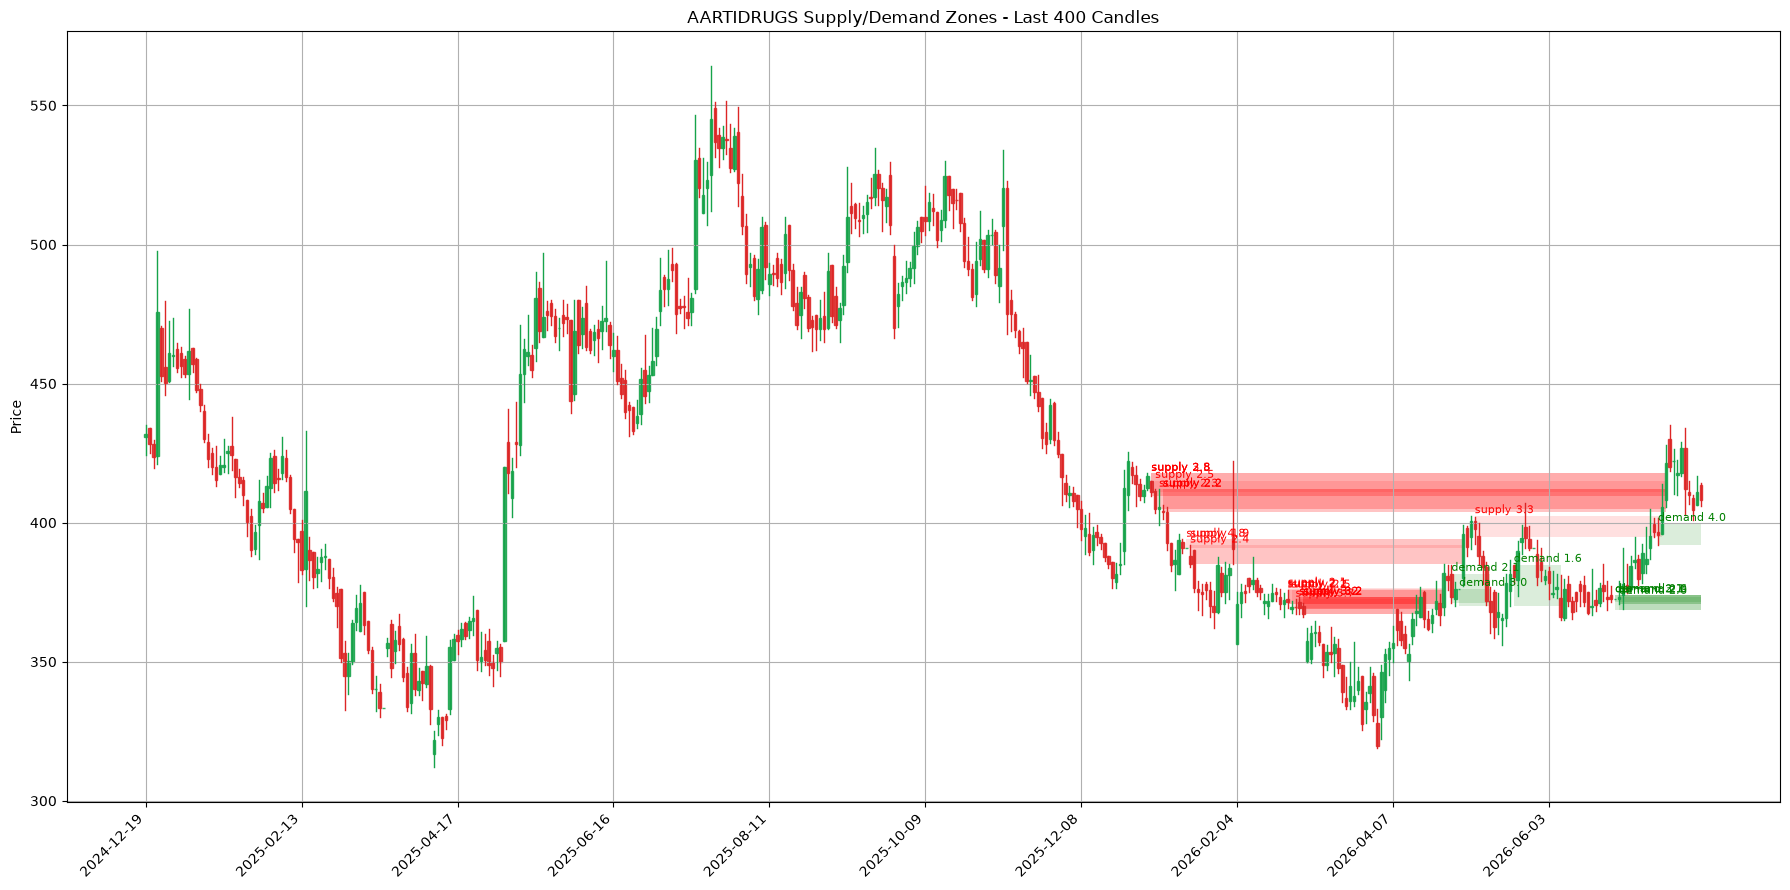

In [5]:
for symbol in list(loaded_stocks.keys())[:3]:
    print(f"\nProcessing {symbol}...")
    df = loaded_stocks[symbol]
    df_processed, zones = detect_supply_demand_zones(df)
    print(f"Detected {len(zones)} zones for {symbol}")
    plot_candles_with_zones(df_processed, zones, symbol, lookback=400, max_zones=30)

## 5. Backtesting Strategy (Return to Origin)

This is a simplistic swing strategy backtester based on the detected zones.
**Rules:**
- **Entry:** Limit buy order when the price drops to touch the Proximal line of a Demand Zone.
- **Stop Loss:** Hard exit if the price drops below the Distal line.
- **Take Profit:** Fixed 1:3 Risk/Reward ratio.

In [6]:
def run_backtest(data, zones_df, target_rr=3.0):
    trades = []
    
    # We only trade long on Demand zones for this MVP
    demand_zones = zones_df[zones_df['type'] == 'demand'].copy()
    
    for _, zone in demand_zones.iterrows():
        zone_created = int(zone['created_idx'])
        zone_invalidated = zone['invalidated_idx']
        proximal = zone['zone_high']
        distal = zone['zone_low']
        
        risk = proximal - distal
        if risk <= 0:
            continue
            
        target = proximal + (risk * target_rr)
        
        # Look at price action AFTER the zone is created
        future_data = data.iloc[zone_created:]
        
        trade_active = False
        entry_price = 0
        entry_idx = 0
        entry_date = None
        
        for i, row in future_data.iterrows():
            # If zone is invalidated before we enter, cancel the limit order
            if i >= zone_invalidated and not trade_active:
                break
                
            # Check for Entry (Price touches proximal line)
            if not trade_active and row['Low'] <= proximal:
                trade_active = True
                entry_price = proximal  
                entry_idx = i
                entry_date = row['Date']
                continue
                
            # If in a trade, check for exits (Take Profit or Stop Loss)
            if trade_active:
                # Target hit
                if row['High'] >= target:
                    trades.append({
                        'entry_date': entry_date,
                        'exit_date': row['Date'],
                        'entry_price': entry_price,
                        'exit_price': target,
                        'result': 'win',
                        'pnl_pct': (target - entry_price) / entry_price * 100,
                        'hold_days': i - entry_idx
                    })
                    break
                    
                # Stop Loss hit (Using Low for strict execution)
                if row['Low'] <= distal:
                    trades.append({
                        'entry_date': entry_date,
                        'exit_date': row['Date'],
                        'entry_price': entry_price,
                        'exit_price': distal,
                        'result': 'loss',
                        'pnl_pct': (distal - entry_price) / entry_price * 100,
                        'hold_days': i - entry_idx
                    })
                    break
                    
    return pd.DataFrame(trades)

print("Backtest function loaded.")

Backtest function loaded.


In [7]:
# Run backtest on all loaded stocks
all_trades = []

for symbol, df in loaded_stocks.items():
    df_processed, zones = detect_supply_demand_zones(df)
    trades_df = run_backtest(df_processed, zones, target_rr=3.0)
    if not trades_df.empty:
        trades_df['symbol'] = symbol
        all_trades.append(trades_df)

if all_trades:
    results = pd.concat(all_trades, ignore_index=True)
    
    total_trades = len(results)
    wins = len(results[results['result'] == 'win'])
    win_rate = (wins / total_trades) * 100
    avg_pnl = results['pnl_pct'].mean()
    avg_hold = results['hold_days'].mean()
    
    print("--- BACKTEST RESULTS (1:3 R/R MVP) ---")
    print(f"Total Trades: {total_trades}")
    print(f"Win Rate:     {win_rate:.2f}%")
    print(f"Avg PnL:      {avg_pnl:.2f}% per trade")
    print(f"Avg Hold:     {avg_hold:.1f} days")
    
    display(results.head(15))
else:
    print("No trades triggered in the sample data.")


--- BACKTEST RESULTS (1:3 R/R MVP) ---
Total Trades: 3004
Win Rate:     45.41%
Avg PnL:      2.00% per trade
Avg Hold:     6.0 days


,entry_date,exit_date,entry_price,exit_price,result,pnl_pct,hold_days,symbol
0,2019-11-27,2019-11-28,306.950012,321.012512,win,4.581365,1,360ONE
1,2019-11-27,2019-11-28,307.337494,322.562439,win,4.953820,1,360ONE
2,2019-11-27,2019-12-09,315.037506,301.524994,loss,-4.289176,8,360ONE
3,2019-11-27,2019-12-09,315.037506,301.524994,loss,-4.289176,8,360ONE
4,2019-12-03,2019-12-06,311.725006,303.062500,loss,-2.778894,3,360ONE
5,2020-01-06,2020-01-08,283.625000,272.500000,loss,-3.922433,2,360ONE
6,2020-01-07,2020-01-08,283.462494,273.600006,loss,-3.479292,1,360ONE
7,2020-01-07,2020-01-08,283.625000,272.500000,loss,-3.922433,1,360ONE
8,2020-01-09,2020-01-10,285.687500,279.287506,loss,-2.240208,1,360ONE
9,2020-01-09,2020-01-17,285.687500,321.949982,win,12.693059,6,360ONE
